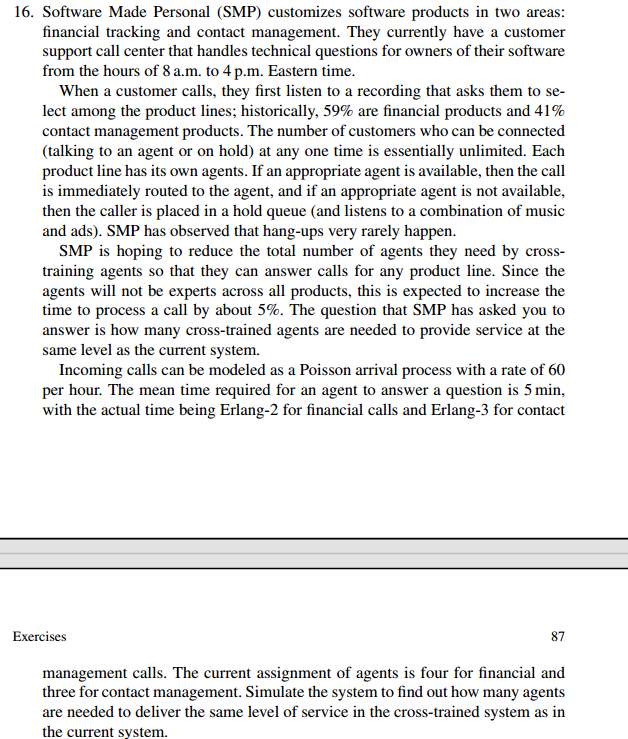

In [11]:
import numpy as np
import json
from collections import deque

In [13]:

RNG = np.random.default_rng(42)

# Erlang-k(mean) => shape k, rate k/mean
def erlang(k, mean, size=1):
    return RNG.gamma(k, mean/k, size)

def arrival():
    None

def sim(n_financial, n_contact, cross_trained=False, n_cross=None,
                   arrival_rate=60/60,  # per minute
                   p_financial=0.59,
                   mean_service=5.0,
                   hours=8,
                   n_reps=20):

    total_min = hours * 60
    results = []

    for rep in range(n_reps):
        # Generate arrivals
        sim_end = total_min 
        # Expected arrivals
        n_arrivals = RNG.poisson(arrival_rate * sim_end)
        # Inter-arrival times => arrival times
        inter = RNG.exponential(1/arrival_rate, n_arrivals)
        arr_times = np.cumsum(inter)
        arr_times = arr_times[arr_times < sim_end]

        # Classify calls
        call_type = RNG.choice(['F','C'], size=len(arr_times),
                               p=[p_financial, 1-p_financial])

        # Service times
        svc = np.where(
            call_type == 'F',
            erlang(2, mean_service, len(arr_times)),
            erlang(3, mean_service, len(arr_times))
        )
        if cross_trained:
            svc *= 1.05  # 5% penalty

        # Agent free-time tracker
        if cross_trained:
            agents = [0.0] * n_cross  # single pool
        else:
            fin_agents = [0.0] * n_financial
            con_agents = [0.0] * n_contact

        wait_times = []
        in_service_times = []

        for i, (t, typ, sv) in enumerate(zip(arr_times, call_type, svc)):
            if cross_trained:
                pool = agents
            else:
                pool = fin_agents if typ == 'F' else con_agents

            # Find earliest-free agent
            earliest = min(pool)
            start = max(t, earliest)
            wait = max(0.0, earliest - t)
            wait_times.append(wait)
            in_service_times.append(sv)

            # Assign to that agent
            idx = pool.index(earliest)
            pool[idx] = start + sv

        # Only count post-warmup
        wt = np.array(wait_times)
        st = np.array(in_service_times)
        types_post = call_type

        results.append({
            'n_calls':len(call_type),
            'mean_wait': wt.mean(),
            'p90_wait': np.percentile(wt, 90),
            'p95_wait': np.percentile(wt, 95),
            'pct_no_wait': (wt == 0).mean() * 100,
            'mean_service': st.mean(),
        })

    # Average across reps
    out = {}
    for k in results[0]:
        vals = [r[k] for r in results]
        out[k] = np.mean(vals)
        out[k+'_ci'] = 1.96 * np.std(vals, ddof=1) / np.sqrt(n_reps)
    return out


In [15]:
# Baseline: 4 financial + 3 contact = 7 agents
print("=== BASELINE SYSTEM (4 fin + 3 contact) ===")
base = sim(4, 3, cross_trained=False)
for k,v in base.items():
    if not k.endswith('_ci'):
        print(f"  {k}: {v:.3f} ± {base[k+'_ci']:.3f}")

print()
print("=== CROSS-TRAINED SYSTEM (varying n_agents) ===")
cross_results = {}
for n in range(5, 12):
    r = sim(0, 0, cross_trained=True, n_cross=n)
    cross_results[n] = r
    print(f"  n={n}: mean_wait={r['mean_wait']:.3f}±{r['mean_wait_ci']:.3f}, "
          f"p90={r['p90_wait']:.3f}, pct_no_wait={r['pct_no_wait']:.1f}%")

# Find minimum n_cross that matches baseline on key metrics
target_wait = base['mean_wait']
target_p90 = base['p90_wait']
target_pnw = base['pct_no_wait']
print(f"\nBaseline targets: mean_wait={target_wait:.3f}, p90={target_p90:.3f}, pct_no_wait={target_pnw:.1f}%")

# Save for visualization
output = {
    'baseline': {k: v for k,v in base.items()},
    'cross': {str(k): {m: v for m,v in r.items()} for k,r in cross_results.items()}
}


=== BASELINE SYSTEM (4 fin + 3 contact) ===
  n_calls: 463.500 ± 5.968
  mean_wait: 1.576 ± 0.239
  p90_wait: 5.381 ± 0.741
  p95_wait: 7.663 ± 1.131
  pct_no_wait: 56.159 ± 3.079
  mean_service: 4.980 ± 0.082

=== CROSS-TRAINED SYSTEM (varying n_agents) ===
  n=5: mean_wait=19.913±4.655, p90=36.730, pct_no_wait=6.4%
  n=6: mean_wait=2.987±0.830, p90=8.266, pct_no_wait=36.8%
  n=7: mean_wait=0.832±0.136, p90=2.932, pct_no_wait=61.6%
  n=8: mean_wait=0.354±0.115, p90=1.412, pct_no_wait=78.4%
  n=9: mean_wait=0.117±0.029, p90=0.229, pct_no_wait=89.2%
  n=10: mean_wait=0.035±0.014, p90=0.000, pct_no_wait=95.9%
  n=11: mean_wait=0.017±0.007, p90=0.000, pct_no_wait=97.6%

Baseline targets: mean_wait=1.576, p90=5.381, pct_no_wait=56.2%
